# 示例 4：蓝筹等权组合（股票）

把资金等权重分配到 5 只蓝筹股，每月重新平衡回等权。

演示「多标的组合」+「月频再平衡」怎么写。

**运行说明**

- 数据：仓库内置 `./data`（全市场 2020 上半年，股票 + 基金）
- 内核：请选择带 `xxybacktest` 依赖的 Python 内核（如本机注册的 `xxybacktest (vnpy)` 环境）。
- 操作：在仓库根目录打开本 notebook，「重启内核并运行所有单元格」即可。
- 回测曲线、回撤与绩效指标表会在最后一个代码单元格运行后自动显示（图已预执行嵌入，离线打开也能直接看）。

In [1]:
%matplotlib inline
from xxybacktest import run_backtest

In [2]:
UNIVERSE = ["600519.SH", "000001.SZ", "600036.SH", "601318.SH", "000858.SZ"]
WEIGHT = 1.0 / len(UNIVERSE)  # 每只等权


def initialize(context):
    context.run_daily(rebalance, "09:31")
    context.last_month = None


def rebalance(context):
    month = context.current_dt.month
    if context.last_month == month:
        return  # 每月只再平衡一次
    context.last_month = month

    target = context.portfolio.total_value * WEIGHT
    for code in UNIVERSE:
        context.order_target_value(code, target)


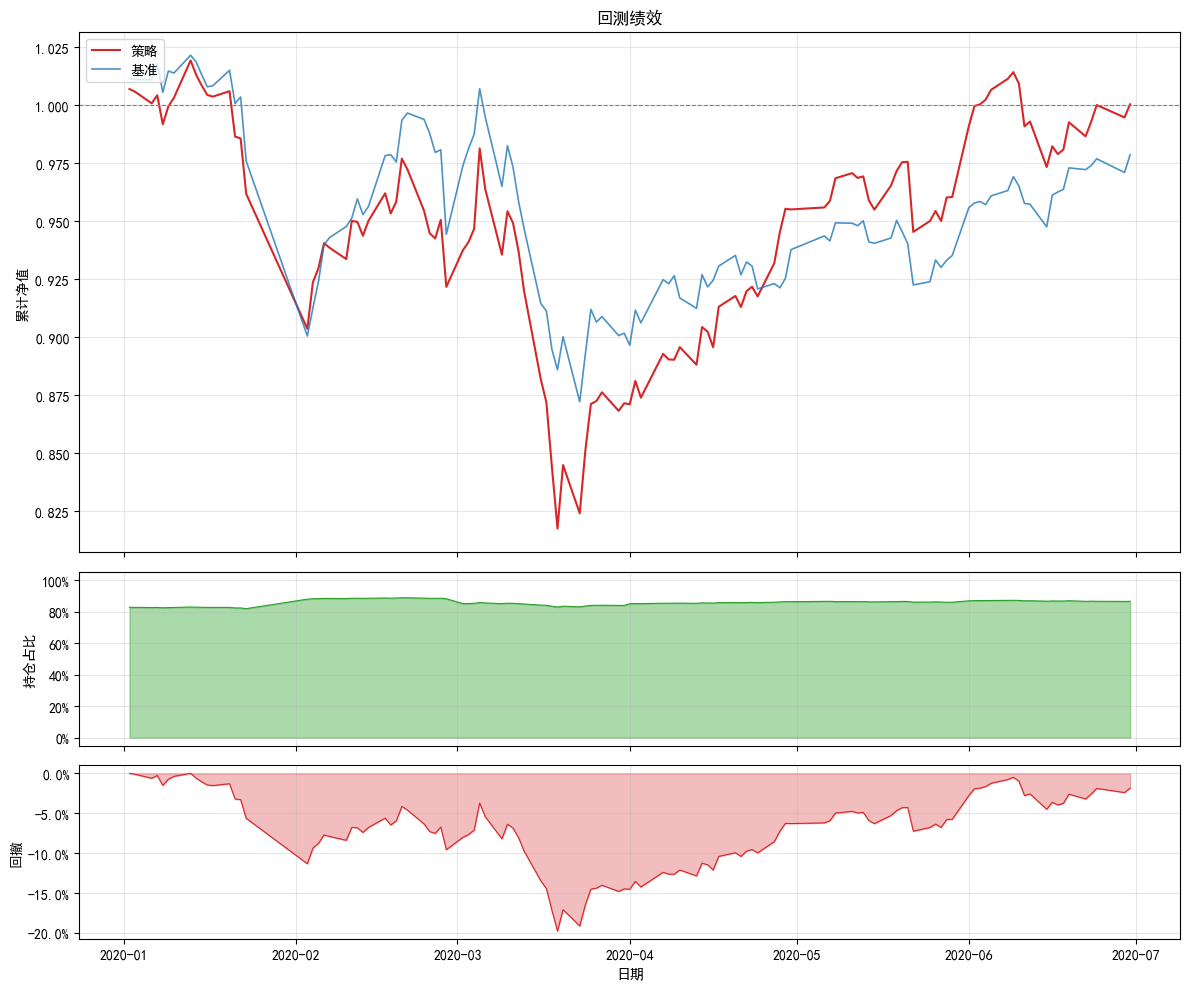

指标,值
总收益率,0.03%
年化收益率,0.07%
CAGR,0.07%
年化波动率,23.63%
最大回撤,-19.79%
夏普比率,0.1210
索提诺比率,0.1600
卡尔玛比率,0.0036
Omega,1.0217
Alpha,0.0517


Loading ITables v2.7.0 from the internet... (need help?)


Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
ctx = run_backtest(
    initialize, None,
    start_date="2020-01-02", end_date="2020-06-30",
    capital=1000000, data_path="../data",
    benchmark="000001.SH", asset_type="stock", plot=True,
)
